In [1]:
import io
import os

import agama
import gc_utils
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable
from PIL import Image
from scipy.interpolate import griddata, interp1d
from scipy.optimize import curve_fit
from scipy.stats import gaussian_kde
from sklearn.svm import SVC

# agama.setUnits(mass=1, length=1, velocity=1)
# units = agama.getUnits()

# plt.rc("font", family="Nimbus Roman")
plt.rc("font", family="Nimbus Roman No9 L")

SMALL_SIZE = 10
MEDIUM_SIZE = 10
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [2]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
sim_cmap = plt.get_cmap("tab10")
sim_colors = [sim_cmap(i) for i in np.linspace(0, 1, len(sim_lst))]

sim_dir = "/Users/z5114326/Documents/simulations/"

snap = 600

public_snapshot_file = sim_dir + "snapshot_times_public.txt"
pub_data = pd.read_table(public_snapshot_file, comment="#", header=None, sep=r"\s+")
pub_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
snap_lst = np.array(pub_data["index"])
timez0 = np.array(pub_data["time_Gyr"])[-1]

In [3]:
sim_dict = {}
for sim in sim_lst:
    ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
    ghost_data = h5py.File(ghost_file, "r")

    sim_dict[sim] = {}
    for it_id in ghost_data.keys():
        src_dat = ghost_data[it_id]["source"]

        amsk = src_dat["grpid"][()] == 0
        grpid = src_dat["grpid"][()]
        samsk = src_dat["sa_flag"][()]

        m_tfo = 10 ** src_dat["logm_tfor"][()]
        m_tfo_ev = 0.55 * (10 ** src_dat["logm_tfor"][()])

        m_tz0_log = src_dat["logm_tz0"][()]
        m_tz0 = np.array([10**x if x != -1 else 0 for x in m_tz0_log])

        tfor = src_dat["tfor"][()]
        tdis = src_dat["tdis"][()]
        tacc = src_dat["tacc"][()]

        r_bir = src_dat["halo.r.birth"][()]

        age = timez0 - tfor
        age_p = np.array([x - y if x != -1 else timez0 - y for x, y in zip(tdis, tfor)])

        t_tz0 = src_dat["torb_600"][()]
        s_tz0 = np.array(src_dat["s_flag"][()], dtype=bool)

        ml = m_tfo_ev - m_tz0
        ml_rate = (m_tfo_ev - m_tz0) / age_p

        sim_dict[sim][it_id] = {}
        sim_dict[sim][it_id]["m_tfo"] = m_tfo
        sim_dict[sim][it_id]["m_tfo_ev"] = m_tfo_ev
        sim_dict[sim][it_id]["m_tz0"] = m_tz0
        sim_dict[sim][it_id]["tfor"] = tfor
        sim_dict[sim][it_id]["tdis"] = tdis
        sim_dict[sim][it_id]["tacc"] = tacc
        sim_dict[sim][it_id]["age"] = age
        sim_dict[sim][it_id]["age_p"] = age_p
        sim_dict[sim][it_id]["t_tz0"] = t_tz0
        sim_dict[sim][it_id]["s_tz0"] = s_tz0
        sim_dict[sim][it_id]["ml"] = ml
        sim_dict[sim][it_id]["ml_rate"] = ml_rate
        sim_dict[sim][it_id]["acc"] = amsk
        sim_dict[sim][it_id]["grp"] = grpid
        sim_dict[sim][it_id]["samsk"] = samsk
        sim_dict[sim][it_id]["r_bir"] = r_bir

Text(0, 0.5, 'Mass at $z=0$ ($M_\\odot$)')

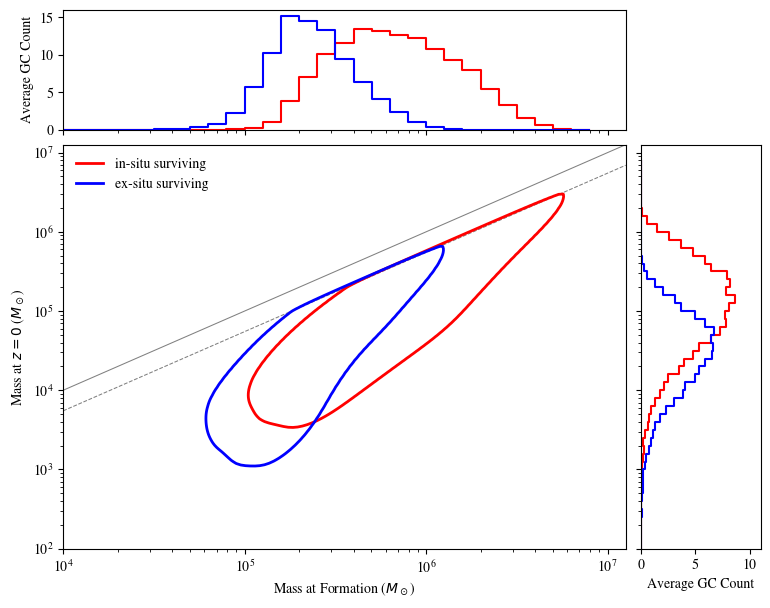

In [4]:
# ------------------------
# Settings
# ------------------------
sim = "m12i"
cont_level = 0.95
hist_density = False

hist_label = "Average GC Count"

# ------------------------
# Figure & axes
# ------------------------
fig, ax_scatter = plt.subplots(figsize=(9, 7))
divider = make_axes_locatable(ax_scatter)

ax_histx = divider.append_axes("top", 1.2, pad=0.15, sharex=ax_scatter)
ax_histy = divider.append_axes("right", 1.2, pad=0.15, sharey=ax_scatter)

# ------------------------
# Reference lines
# ------------------------
x_fit = np.logspace(4, 7.1)
ax_scatter.plot(x_fit, 0.55 * x_fit, c="grey", lw=0.75, ls="--")
ax_scatter.plot(x_fit, x_fit, c="grey", lw=0.75)

# ------------------------
# KDE grid (log–log)
# ------------------------
logx_grid = np.linspace(2, 7.2, 200)
logy_grid = np.linspace(2, 7.2, 200)
XX, YY = np.meshgrid(logx_grid, logy_grid)
grid_positions = np.vstack([XX.ravel(), YY.ravel()])

# ------------------------
# Histogram bins
# ------------------------
histx_bins = np.logspace(3, 7, 41)
histy_bins = np.logspace(1, 7, 61)

# ------------------------
# Histogram accumulators
# ------------------------
hist_dict = {
    "in-situ": {"x_sum": None, "y_sum": None, "n_iter": 0},
    "ex-situ": {"x_sum": None, "y_sum": None, "n_iter": 0},
}

# ------------------------
# Main loop
# ------------------------
for acc in [0, 1]:
    if acc == 0:
        acc_lab = "in-situ"
        color = "r"
    else:
        acc_lab = "ex-situ"
        color = "b"

    Z_list = []

    for it_id in sim_dict[sim].keys():
        smsk = sim_dict[sim][it_id]["s_tz0"]

        if acc == 0:
            amsk = sim_dict[sim][it_id]["acc"]
        else:
            amsk = ~sim_dict[sim][it_id]["acc"]

        msk = smsk & amsk

        x = sim_dict[sim][it_id]["m_tfo"][msk]
        y = sim_dict[sim][it_id]["m_tz0"][msk]

        # Enforce physical bound
        bound = y <= 0.55 * x
        x = x[bound]
        y = y[bound]

        if len(x) < 20:
            continue

        # ------------------------
        # KDE (per iteration)
        # ------------------------
        logx = np.log10(x)
        logy = np.log10(y)

        kde = gaussian_kde(np.vstack([logx, logy]))
        Z = kde(grid_positions).reshape(XX.shape)

        Z /= Z.sum()  # equal weight per iteration
        Z_list.append(Z)

        # ------------------------
        # Histograms (per iteration)
        # ------------------------
        hx, _ = np.histogram(x, bins=histx_bins)
        hy, _ = np.histogram(y, bins=histy_bins)

        if hist_dict[acc_lab]["x_sum"] is None:
            hist_dict[acc_lab]["x_sum"] = hx.astype(float)
            hist_dict[acc_lab]["y_sum"] = hy.astype(float)
        else:
            hist_dict[acc_lab]["x_sum"] += hx
            hist_dict[acc_lab]["y_sum"] += hy

        hist_dict[acc_lab]["n_iter"] += 1

    if len(Z_list) == 0:
        continue

    # ------------------------
    # Average KDE
    # ------------------------
    Z_avg = np.mean(Z_list, axis=0)

    # Mask unphysical region
    log_bound = np.log10(0.55) + XX
    Z_avg[YY > log_bound] = 0

    # ------------------------
    # Contour level
    # ------------------------
    Zf = Z_avg.ravel()
    idx = np.argsort(Zf)[::-1]
    Zs = Zf[idx]

    cdf = np.cumsum(Zs)
    cdf /= cdf[-1]

    level = Zs[np.searchsorted(cdf, cont_level)]

    ax_scatter.contour(
        10**XX,
        10**YY,
        Z_avg,
        levels=[level],
        colors=color,
        linewidths=2,
    )

# ------------------------
# Legend
# ------------------------
ax_scatter.legend(
    handles=[
        Line2D([0], [0], color="r", lw=2, label="in-situ surviving"),
        Line2D([0], [0], color="b", lw=2, label="ex-situ surviving"),
    ],
    frameon=False,
)

# ------------------------
# Average histograms
# ------------------------
hist_avg = {}
for acc_lab in ["in-situ", "ex-situ"]:
    n = hist_dict[acc_lab]["n_iter"]
    hist_avg[acc_lab] = {
        "x": hist_dict[acc_lab]["x_sum"] / n,
        "y": hist_dict[acc_lab]["y_sum"] / n,
    }

# X histogram
ax_histx.step(histx_bins[:-1], hist_avg["in-situ"]["x"], where="post", color="r")
ax_histx.step(histx_bins[:-1], hist_avg["ex-situ"]["x"], where="post", color="b")
# ax_histx.set_yscale("log")
ax_histx.set_ylabel(hist_label)
ax_histx.tick_params(labelbottom=False)
ax_histx.set_yticks([0, 5, 10, 15])
ax_histx.set_ylim([0, 16])

# Y histogram
ax_histy.step(hist_avg["in-situ"]["y"], histy_bins[:-1], where="post", color="r")
ax_histy.step(hist_avg["ex-situ"]["y"], histy_bins[:-1], where="post", color="b")
# ax_histy.set_xscale("log")
ax_histy.set_xlabel(hist_label)
ax_histy.tick_params(labelleft=False)
ax_histy.set_xticks([0, 5, 10])
ax_histy.set_xlim([0, 11])

# ------------------------
# Axes formatting
# ------------------------
ax_scatter.set_xscale("log")
ax_scatter.set_yscale("log")
ax_scatter.set_xlim(1e4, 10**7.1)
ax_scatter.set_ylim(1e2, 10**7.1)
ax_scatter.set_xlabel(r"Mass at Formation ($M_\odot$)")
ax_scatter.set_ylabel(r"Mass at $z=0$ ($M_\odot$)")


Could i colour by distance from centre of formation halo, or age?

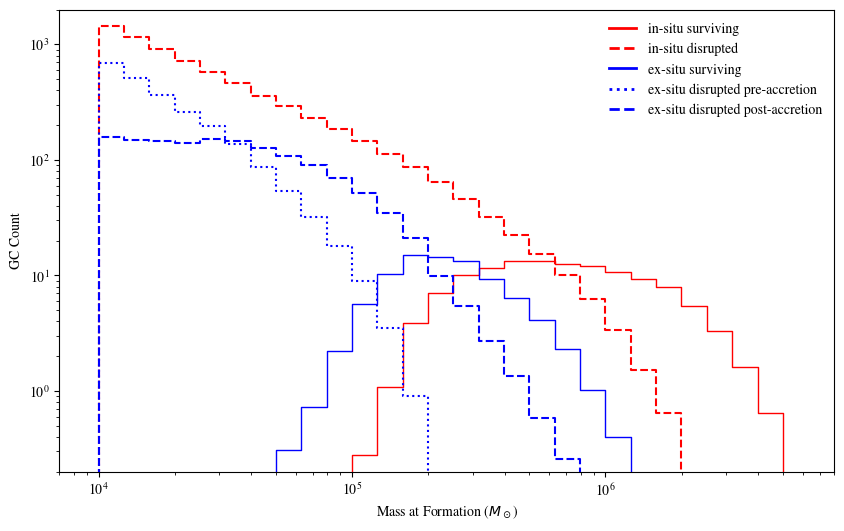

In [5]:
plt_alive = True
plt_dead = True

hist_dict = {
    "in-situ": {
        "s": {"x_sum": None, "y_sum": None, "n_iter": 0},
        "d": {"x_sum": None, "y_sum": None, "n_iter": 0},
    },
    "ex-situ": {
        "s": {"x_sum": None, "y_sum": None, "n_iter": 0},
        "db": {"x_sum": None, "y_sum": None, "n_iter": 0},
        "da": {"x_sum": None, "y_sum": None, "n_iter": 0},
    },
}

for acc in [0, 1]:
    if acc == 0:
        acc_lab = "in-situ"
        color = "r"
    else:
        acc_lab = "ex-situ"
        color = "b"

    Z_list = []

    for key in hist_dict[acc_lab].keys():
        for it_id in sim_dict[sim].keys():
            if key == "s":
                smsk = sim_dict[sim][it_id]["s_tz0"]
            else:
                smsk = ~sim_dict[sim][it_id]["s_tz0"]

            if acc == 0:
                amsk = sim_dict[sim][it_id]["acc"]
                samsk = np.ones(len(amsk), dtype=bool)
            else:
                amsk = ~sim_dict[sim][it_id]["acc"]
                if (key == "da") | (key == "s"):
                    samsk = np.array(sim_dict[sim][it_id]["samsk"], dtype=bool)
                else:
                    samsk = ~np.array(sim_dict[sim][it_id]["samsk"], dtype=bool)

            msk = smsk & amsk & samsk

            x = sim_dict[sim][it_id]["m_tfo"][msk]
            y = sim_dict[sim][it_id]["m_tz0"][msk]

            bound = y <= 0.55 * x
            x = x[bound]
            y = y[bound]

            if len(x) < 20:
                continue

            hx, _ = np.histogram(x, bins=histx_bins)
            hy, _ = np.histogram(y, bins=histy_bins)

            if hist_dict[acc_lab][key]["x_sum"] is None:
                hist_dict[acc_lab][key]["x_sum"] = hx.astype(float)
                hist_dict[acc_lab][key]["y_sum"] = hy.astype(float)
            else:
                hist_dict[acc_lab][key]["x_sum"] += hx
                hist_dict[acc_lab][key]["y_sum"] += hy

            hist_dict[acc_lab][key]["n_iter"] += 1

hist_avg = {}
for acc_lab in ["in-situ", "ex-situ"]:
    hist_avg[acc_lab] = {}
    for key in hist_dict[acc_lab].keys():
        n = hist_dict[acc_lab][key]["n_iter"]
        hist_avg[acc_lab][key] = {"x": hist_dict[acc_lab][key]["x_sum"] / n}


hist_density = False

if hist_density:
    hist_label = "Density"
else:
    hist_label = "GC Count"

# IMPORTANT: aspect must be measured AFTER draw
fig.canvas.draw()

aspect = ax_histx.get_position().width / ax_histx.get_position().height

# fig_w = 10.0
# fig_h = fig_w / aspect

# fig, ax = plt.subplots(figsize=(fig_w, fig_h))
fig, ax = plt.subplots(figsize=(10, 6))

# histx_bins = np.logspace(3.9, 7, 32)

legend_handles = []

if plt_alive:
    ax.step(histx_bins[:-1], hist_avg["in-situ"]["s"]["x"], where="post", color="r", lw=1)
    ax.step(histx_bins[:-1], hist_avg["ex-situ"]["s"]["x"], where="post", color="b", lw=1)

    legend_handles.append(Line2D([0], [0], color="r", lw=2, label="in-situ surviving"))
    legend_handles.append(Line2D([0], [0], color="r", lw=2, label="in-situ disrupted", ls="--"))

if plt_dead:
    ax.step(histx_bins[:-1], hist_avg["in-situ"]["d"]["x"], where="post", color="r", ls="--")
    ax.step(histx_bins[:-1], hist_avg["ex-situ"]["db"]["x"], where="post", color="b", ls="dotted")
    ax.step(histx_bins[:-1], hist_avg["ex-situ"]["da"]["x"], where="post", color="b", ls="--")

    legend_handles.append(Line2D([0], [0], color="b", lw=2, label="ex-situ surviving"))
    legend_handles.append(
        Line2D([0], [0], color="b", lw=2, label="ex-situ disrupted pre-accretion", ls="dotted")
    )
    legend_handles.append(
        Line2D([0], [0], color="b", lw=2, label="ex-situ disrupted post-accretion", ls="--")
    )


ax.set_xscale("log")

ax.set_ylabel(hist_label)
ax.set_xlabel(r"Mass at Formation ($M_\odot$)")

ax.set_xlim(7 * 10**3, 8 * 10**6)

ax.set_yscale("log")
ax.set_ylim(2 * 10**-1, 2 * 10**3)

# ax.set_yticks([0, 5, 10, 15])
# ax.set_ylim([0, 16])


ax.legend(handles=legend_handles, frameon=False)

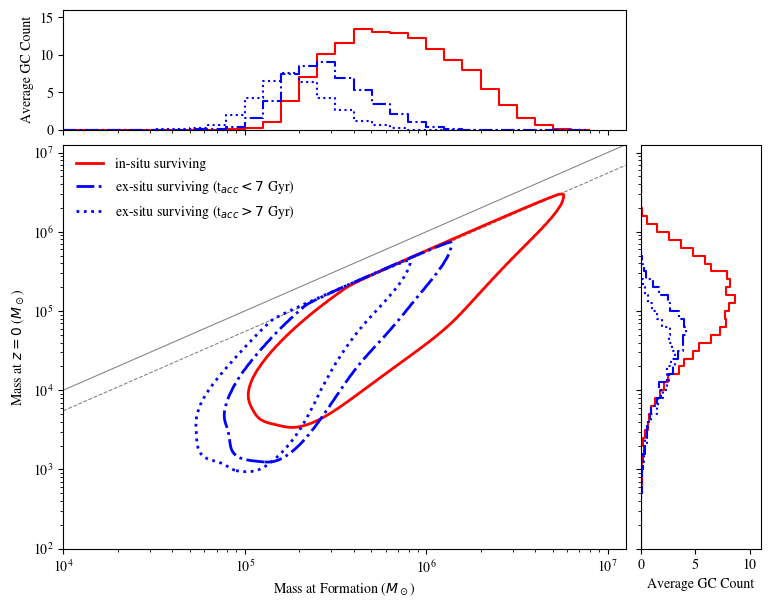

In [6]:
# ------------------------
# Settings
# ------------------------
sim = "m12i"
cont_level = 0.95
hist_density = False
tacc_break = 7

hist_label = "Density" if hist_density else "Average GC Count"

# ------------------------
# Figure & axes
# ------------------------
fig, ax_scatter = plt.subplots(figsize=(9, 7))
divider = make_axes_locatable(ax_scatter)

ax_histx = divider.append_axes("top", 1.2, pad=0.15, sharex=ax_scatter)
ax_histy = divider.append_axes("right", 1.2, pad=0.15, sharey=ax_scatter)

# ------------------------
# Reference lines
# ------------------------
x_fit = np.logspace(4, 7.1)
ax_scatter.plot(x_fit, 0.55 * x_fit, c="grey", lw=0.75, ls="--")
ax_scatter.plot(x_fit, x_fit, c="grey", lw=0.75)

# ------------------------
# KDE grid (log–log)
# ------------------------
logx_grid = np.linspace(2, 7.2, 200)
logy_grid = np.linspace(2, 7.2, 200)
XX, YY = np.meshgrid(logx_grid, logy_grid)
grid_positions = np.vstack([XX.ravel(), YY.ravel()])

# ------------------------
# Histogram bins
# ------------------------
histx_bins = np.logspace(4, 7, 31)
histy_bins = np.logspace(1, 7, 61)

# ------------------------
# Histogram accumulators
# ------------------------
hist_dict = {
    "in-situ": {"x_sum": None, "y_sum": None, "n_iter": 0},
    "ex-situ_e": {"x_sum": None, "y_sum": None, "n_iter": 0},
    "ex-situ_l": {"x_sum": None, "y_sum": None, "n_iter": 0},
}

# ------------------------
# Main loop
# ------------------------
for acc in [0, 1, 2]:
    Z_list = []

    if acc == 0:
        acc_lab, color, ls = "in-situ", "r", "-"
    elif acc == 1:
        acc_lab, color, ls = "ex-situ_e", "b", "-."
    else:
        acc_lab, color, ls = "ex-situ_l", "b", ":"

    for it_id in sim_dict[sim]:
        smsk = sim_dict[sim][it_id]["s_tz0"]

        if acc == 0:
            amsk = sim_dict[sim][it_id]["acc"]
            tmsk = np.ones_like(smsk, dtype=bool)
        elif acc == 1:
            amsk = ~sim_dict[sim][it_id]["acc"]
            tmsk = sim_dict[sim][it_id]["tacc"] <= tacc_break
        else:
            amsk = ~sim_dict[sim][it_id]["acc"]
            tmsk = sim_dict[sim][it_id]["tacc"] > tacc_break

        msk = smsk & amsk & tmsk

        x = sim_dict[sim][it_id]["m_tfo"][msk]
        y = sim_dict[sim][it_id]["m_tz0"][msk]

        # Remove invalid values
        valid = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
        x, y = x[valid], y[valid]

        # Physical bound
        bound = y <= 0.55 * x
        x, y = x[bound], y[bound]

        if len(x) < 20:
            continue

        # ------------------------
        # KDE (per iteration)
        # ------------------------
        logx = np.log10(x)
        logy = np.log10(y)

        kde = gaussian_kde(np.vstack([logx, logy]))
        Z = kde(grid_positions).reshape(XX.shape)
        Z /= Z.sum()  # equal iteration weight

        Z_list.append(Z)

        # ------------------------
        # Histograms (per iteration)
        # ------------------------
        hx, _ = np.histogram(x, bins=histx_bins)
        hy, _ = np.histogram(y, bins=histy_bins)

        if hist_dict[acc_lab]["x_sum"] is None:
            hist_dict[acc_lab]["x_sum"] = hx.astype(float)
            hist_dict[acc_lab]["y_sum"] = hy.astype(float)
        else:
            hist_dict[acc_lab]["x_sum"] += hx
            hist_dict[acc_lab]["y_sum"] += hy

        hist_dict[acc_lab]["n_iter"] += 1

    if not Z_list:
        continue

    # ------------------------
    # Average KDE
    # ------------------------
    Z_avg = np.mean(Z_list, axis=0)

    # Mask unphysical region
    Z_avg[YY > np.log10(0.55) + XX] = 0

    # ------------------------
    # Contour level (CDF method)
    # ------------------------
    Zf = Z_avg.ravel()
    idx = np.argsort(Zf)[::-1]
    Zs = Zf[idx]

    cdf = np.cumsum(Zs)
    cdf /= cdf[-1]

    level = Zs[np.searchsorted(cdf, cont_level)]

    ax_scatter.contour(
        10**XX,
        10**YY,
        Z_avg,
        levels=[level],
        colors=color,
        linewidths=2,
        linestyles=ls,
    )

# ------------------------
# Average histograms
# ------------------------
hist_avg = {}
for k in hist_dict:
    n = hist_dict[k]["n_iter"]
    hist_avg[k] = {
        "x": hist_dict[k]["x_sum"] / n if n > 0 else None,
        "y": hist_dict[k]["y_sum"] / n if n > 0 else None,
    }

# X histogram
bx = histx_bins[:-1]
ax_histx.step(bx, hist_avg["in-situ"]["x"], where="post", color="r")
ax_histx.step(bx, hist_avg["ex-situ_e"]["x"], where="post", color="b", ls="-.")
ax_histx.step(bx, hist_avg["ex-situ_l"]["x"], where="post", color="b", ls=":")
ax_histx.set_ylabel(hist_label)
# ax_histx.set_yscale("log")
ax_histx.set_yticks([0, 5, 10, 15])
ax_histx.set_ylim([0, 16])
ax_histx.tick_params(labelbottom=False)

# Y histogram
by = histy_bins[:-1]
ax_histy.step(hist_avg["in-situ"]["y"], by, where="post", color="r")
ax_histy.step(hist_avg["ex-situ_e"]["y"], by, where="post", color="b", ls="-.")
ax_histy.step(hist_avg["ex-situ_l"]["y"], by, where="post", color="b", ls=":")
ax_histy.set_xlabel(hist_label)
# ax_histy.set_xscale("log")
ax_histy.set_xticks([0, 5, 10])
ax_histy.set_xlim([0, 11])
ax_histy.tick_params(labelleft=False)

# ------------------------
# Axes formatting
# ------------------------
ax_scatter.set_xscale("log")
ax_scatter.set_yscale("log")
ax_scatter.set_xlim(1e4, 10**7.1)
ax_scatter.set_ylim(1e2, 10**7.1)
ax_scatter.set_xlabel(r"Mass at Formation ($M_\odot$)")
ax_scatter.set_ylabel(r"Mass at $z=0$ ($M_\odot$)")

ax_scatter.legend(
    handles=[
        Line2D([0], [0], color="r", lw=2, ls="-", label="in-situ surviving"),
        Line2D([0], [0], color="b", lw=2, ls="-.", label="ex-situ surviving (t$_{acc} < 7$ Gyr)"),
        Line2D([0], [0], color="b", lw=2, ls=":", label="ex-situ surviving (t$_{acc} > 7$ Gyr)"),
    ],
    frameon=False,
)


In [7]:
src_dat.keys()

<KeysViewHDF5 ['feh', 'gcid', 'grpid', 'halo.r.avg', 'halo.r.avg.pre', 'halo.r.birth', 'halo_tfor', 'host.r.avg', 'host.r.avg.pos', 'host.r.avg.pre', 'host.r.birth', 'logm_tfor', 'logm_tz0', 'pidx_snap600', 'ptype', 'pxyz_snap600', 's_flag', 'sa_flag', 'snap_tacc', 'snap_tfor', 'snap_tforp', 'tacc', 'tdis', 'tfor', 'tideig.avg', 'tideig.avg.pos', 'tideig.avg.pre', 'torb_600', 'vxyz_snap600']>

In [8]:
mass_dict = {sim: {it_id: {} for it_id in sim_dict[sim].keys()} for sim in sim_lst}

for sim in mass_dict.keys():
    ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
    ghost_data = h5py.File(ghost_file, "r")

    for it_id in sim_dict[sim].keys():
        src_dat = ghost_data[it_id]["source"]
        smsk = src_dat["s_flag"][()].astype(bool)

        gcids = src_dat["gcid"][smsk]
        taccs = src_dat["tacc"][smsk]
        tfors = src_dat["tfor"][smsk]
        tz0s = src_dat["torb_600"][smsk]
        mtfors = 10 ** src_dat["logm_tfor"][smsk]
        mtforevs = 0.55 * mtfors
        mz0s = 10 ** src_dat["logm_tz0"][smsk]

        grps = src_dat["grpid"][smsk]

        samsks = src_dat["sa_flag"][smsk].astype(bool)
        amsks = src_dat["grpid"][smsk] == 0

        data_dict = {
            gcid: {
                "t_snp": [],
                "m_snp": [],
                "tacc": tacc,
                "tfor": tfor,
                "pz0": tz0,
                "mtfor": mtfor,
                "mtforev": mtforev,
                "mz0": mz0,
                "samsk": samsk,
                "amsk": amsk,
                "grp": grp,
            }
            for gcid, tacc, tfor, tz0, mtfor, mtforev, mz0, samsk, amsk, grp in zip(
                gcids, taccs, tfors, tz0s, mtfors, mtforevs, mz0s, samsks, amsks, grps
            )
        }

        for snap in snap_lst:
            snap_id = gc_utils.snapshot_name(snap)
            time = float(pub_data[pub_data["index"] == snap]["time_Gyr"].values[0])

            snp_dat = ghost_data[it_id]["snapshots"][snap_id]
            gcids_snp = snp_dat["gcid"][()]
            mass_snp = 10 ** snp_dat["logm"][()]

            gcid_msk = np.isin(gcids_snp, gcids)
            gc_snp_dict = {gcids_snp[idx]: idx for idx in np.nonzero(gcid_msk)[0]}

            for gcid in gcids:
                if gcid not in gcids_snp:
                    data_dict[gcid]["m_snp"].append(np.nan)
                    data_dict[gcid]["t_snp"].append(np.nan)
                    continue
                gcidx = gc_snp_dict[gcid]
                data_dict[gcid]["m_snp"].append(mass_snp[gcidx])
                data_dict[gcid]["t_snp"].append(time)

        mass_dict[sim][it_id] = data_dict

for sim in sim_lst:
    for it_id in mass_dict[sim].keys():
        for gcid in mass_dict[sim][it_id].keys():
            # extract masses and times, remove NaNs
            masses = np.array(mass_dict[sim][it_id][gcid]["m_snp"])
            times = np.array(mass_dict[sim][it_id][gcid]["t_snp"])
            valid = ~np.isnan(masses) & ~np.isnan(times)
            masses = masses[valid]
            times = times[valid]

            # add formation mass/time at start
            masses = np.insert(masses, 0, mass_dict[sim][it_id][gcid]["mtforev"])
            times = np.insert(times, 0, mass_dict[sim][it_id][gcid]["tfor"])

            # remove tiny dt intervals, keep last point
            dt = np.diff(times)
            # mask = np.insert(dt > 0.01, 0, True)  # keep first point, remove very tiny intervals
            mask = np.append(dt > 0.01, True)  # keep last point, remove very tiny intervals
            masses_clean = masses[mask]
            times_clean = times[mask]

            mass_dict[sim][it_id][gcid]["mass_clean"] = masses_clean
            mass_dict[sim][it_id][gcid]["time_clean"] = times_clean

for sim in sim_lst:
    for it_id in mass_dict[sim].keys():
        for gcid in mass_dict[sim][it_id].keys():
            mass = mass_dict[sim][it_id][gcid]["mass_clean"]
            time = mass_dict[sim][it_id][gcid]["time_clean"]

            gamma_mov = []
            for i in range(1, len(mass)):
                gamma_mov_i = (1 / (time[i] - time[i - 1])) * np.log(mass[i - 1] / mass[i])
                gamma_mov.append(gamma_mov_i)

            mass_dict[sim][it_id][gcid]["gamma_mov"] = np.array(gamma_mov)

In [9]:
# loop over clusters
for sim in mass_dict.keys():
    for it_id in mass_dict[sim].keys():
        for gcid in mass_dict[sim][it_id].keys():
            tacc = mass_dict[sim][it_id][gcid]["tacc"]
            tfor = mass_dict[sim][it_id][gcid]["tfor"]
            if tacc == -1:
                continue

            masses = mass_dict[sim][it_id][gcid]["mass_clean"]
            times = mass_dict[sim][it_id][gcid]["time_clean"]

            if len(masses) <= 1 or len(times) <= 1:
                mass_dict[sim][it_id][gcid]["gamma_pre"] = np.nan
                mass_dict[sim][it_id][gcid]["gamma_pos"] = np.nan
                mass_dict[sim][it_id][gcid]["gamma_ful"] = np.nan
                continue

            f_cubic = interp1d(times, masses, kind="cubic")

            mforev = mass_dict[sim][it_id][gcid]["mtforev"]
            macc = f_cubic(tacc)
            mz0 = mass_dict[sim][it_id][gcid]["m_snp"][-1]

            if mforev <= 0 or macc <= 0 or mz0 <= 0:
                gamma_pre = np.nan
                gamma_pos = np.nan
                gamma_ful = np.nan
            else:
                gamma_pre = (1 / (tacc - tfor)) * np.log(mforev / macc)
                gamma_pos = (1 / (timez0 - tacc)) * np.log(macc / mz0)
                gamma_ful = (1 / (timez0 - tfor)) * np.log(mforev / mz0)

            mass_dict[sim][it_id][gcid]["gamma_pre"] = gamma_pre
            mass_dict[sim][it_id][gcid]["gamma_pos"] = gamma_pos
            mass_dict[sim][it_id][gcid]["gamma_ful"] = gamma_ful

In [10]:
# loop over clusters
# for sim in mass_dict.keys():
sim = "m12i"
for it_id in mass_dict[sim].keys():
    for gcid in mass_dict[sim][it_id].keys():
        grp = mass_dict[sim][it_id][gcid]["grp"]
        if grp != 0:
            continue
        masses = mass_dict[sim][it_id][gcid]["mass_clean"]
        times = mass_dict[sim][it_id][gcid]["time_clean"]

        if len(masses) <= 1 or len(times) <= 1:
            mass_dict[sim][it_id][gcid]["gamma_ful"] = np.nan

        f_cubic = interp1d(times, masses, kind="cubic")

        mforev = mass_dict[sim][it_id][gcid]["mtforev"]
        mz0 = mass_dict[sim][it_id][gcid]["m_snp"][-1]

        if mforev <= 0 or mz0 <= 0:
            gamma_ful = np.nan
        else:
            gamma_ful = (1 / (timez0 - tfor)) * np.log(mforev / mz0)

        mass_dict[sim][it_id][gcid]["gamma_ful"] = gamma_ful

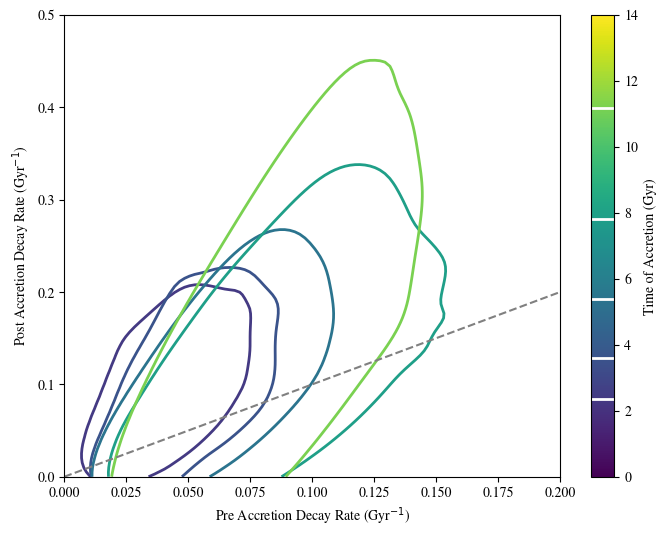

In [11]:
sim = "m12i"

# --------------------------------------------------
# PARAMETERS
# --------------------------------------------------
xlim = (0, 0.2)
# ylim = (0, 0.85)
ylim = (0, 0.5)
min_gc_per_grp_avg = 5  # average minimum GCs per group across iterations
epsilon = 1e-6  # tiny jitter for KDE stability
cmap = plt.get_cmap("viridis")  # colormap

# --------------------------------------------------
# COMPUTE GROUP COUNTS AND TACC ACROSS ITERATIONS
# --------------------------------------------------
grp_counts = {}  # key = grp, value = list of counts per iteration
grp_tacc = {}  # key = grp, value = list of tacc values

for it_id in mass_dict[sim].keys():
    counts_in_it = {}
    for gcid in mass_dict[sim][it_id].keys():
        grp = mass_dict[sim][it_id][gcid]["grp"]
        tacc = mass_dict[sim][it_id][gcid]["tacc"]
        if tacc == -1:
            continue
        counts_in_it[grp] = counts_in_it.get(grp, 0) + 1
        grp_tacc.setdefault(grp, []).append(tacc)
    # append counts per iteration
    for grp, cnt in counts_in_it.items():
        grp_counts.setdefault(grp, []).append(cnt)

# Only keep groups with average ≥ min_gc_per_grp_avg
valid_grps = [grp for grp, counts in grp_counts.items() if np.mean(counts) >= min_gc_per_grp_avg]

# --------------------------------------------------
# BIN DATA BY GROUP
# --------------------------------------------------
binned_data = {grp: {"gamma_pre": [], "gamma_pos": [], "tacc": None} for grp in valid_grps}

for grp in valid_grps:
    # mean tacc for the group
    binned_data[grp]["tacc"] = np.mean(grp_tacc[grp])

for it_id in mass_dict[sim].keys():
    for gcid in mass_dict[sim][it_id].keys():
        grp = mass_dict[sim][it_id][gcid]["grp"]
        if grp not in valid_grps:
            continue  # skip invalid groups
        tacc = mass_dict[sim][it_id][gcid]["tacc"]
        if tacc == -1:
            continue  # only accreted GCs
        binned_data[grp]["gamma_pre"].append(mass_dict[sim][it_id][gcid]["gamma_pre"])
        binned_data[grp]["gamma_pos"].append(mass_dict[sim][it_id][gcid]["gamma_pos"])


# --------------------------------------------------
# FUNCTION TO COMPUTE CONTOUR LEVEL (CDF METHOD)
# --------------------------------------------------
def kde_cdf_level(Z, frac=0.75):
    Zf = Z.ravel()
    idx = np.argsort(Zf)[::-1]
    Zs = Zf[idx]
    cdf = np.cumsum(Zs)
    cdf /= cdf[-1]
    return Zs[np.searchsorted(cdf, frac)]


fig, ax = plt.subplots(figsize=(8, 6))

all_tacc = [data["tacc"] for data in binned_data.values()]
if len(all_tacc) == 0:
    raise RuntimeError("No valid groups to plot! Check your min_gc_per_grp_avg or data.")
norm = plt.Normalize(vmin=0, vmax=14)

xgrid = np.linspace(*xlim, 100)
ygrid = np.linspace(*ylim, 100)
X, Y = np.meshgrid(xgrid, ygrid)
grid_positions = np.vstack([X.ravel(), Y.ravel()])

for grp, data in binned_data.items():
    Z_list = []

    for it_id in mass_dict[sim].keys():
        # collect per-iteration points
        x_it, y_it = [], []

        for gcid in mass_dict[sim][it_id].keys():
            g = mass_dict[sim][it_id][gcid]["grp"]
            if g != grp:
                continue

            tacc = mass_dict[sim][it_id][gcid]["tacc"]
            if tacc == -1:
                continue

            x_it.append(mass_dict[sim][it_id][gcid]["gamma_pre"])
            y_it.append(mass_dict[sim][it_id][gcid]["gamma_pos"])

        x_it = np.array(x_it)
        y_it = np.array(y_it)

        mask = np.isfinite(x_it) & np.isfinite(y_it)
        x_it, y_it = x_it[mask], y_it[mask]

        if len(x_it) < 5:
            continue

        # jitter
        x_it += np.random.normal(0, epsilon, len(x_it))
        y_it += np.random.normal(0, epsilon, len(y_it))

        # KDE per iteration
        kde = gaussian_kde(np.vstack([x_it, y_it]))
        Z = kde(grid_positions).reshape(X.shape)

        Z /= Z.sum()
        Z_list.append(Z)

    if len(Z_list) == 0:
        continue

    # --------------------------------------------------
    # Average KDE
    # --------------------------------------------------
    Z_avg = np.mean(Z_list, axis=0)

    # --------------------------------------------------
    # 75% contour (CDF-based)
    # --------------------------------------------------
    level_75 = kde_cdf_level(Z_avg, frac=0.75)

    ax.contour(
        X,
        Y,
        Z_avg,
        levels=[level_75],
        colors=[cmap(norm(data["tacc"]))],
        linewidths=2,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Time of Accretion (Gyr)")

ax.plot([0, 1], [0, 1], c="grey", ls="--")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel("Pre Accretion Decay Rate (Gyr$^{-1}$)")
ax.set_ylabel("Post Accretion Decay Rate (Gyr$^{-1}$)")


# Put ticks on top (optional, looks nicer for top colorbar)
# cax.xaxis.set_ticks_position("top")
# cax.xaxis.set_label_position("top")

for tacc in all_tacc:
    cbar.ax.axhline(tacc, color="w", lw=2.0, ls="-")

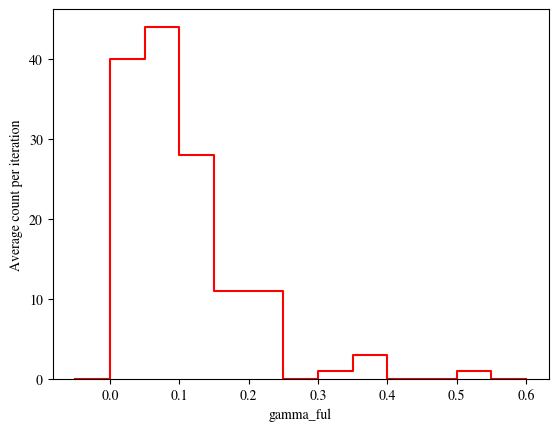

In [12]:
bins = np.arange(-0.05, 0.7, 0.05)

res = None
n_iter = 0

# for it_id in mass_dict[sim].keys():
it_id = "it000"
gam_lst = []

for gcid in mass_dict[sim][it_id].keys():
    if mass_dict[sim][it_id][gcid]["grp"] != 0:
        continue
    gam_lst.append(mass_dict[sim][it_id][gcid]["gamma_ful"])

hx, _ = np.histogram(gam_lst, bins=bins)

if res is None:
    res = hx.astype(float)
else:
    res += hx

n_iter += 1

avg = res / n_iter

# STEP HISTOGRAM — SAME STYLE AS YOUR WORKING CASE
plt.step(bins[:-1], avg, where="post", lw=1.5, c="r")

plt.xlabel("gamma_ful")
plt.ylabel("Average count per iteration")
# plt.xlim(0.5, 0)
plt.ylim(bottom=0)
plt.show()

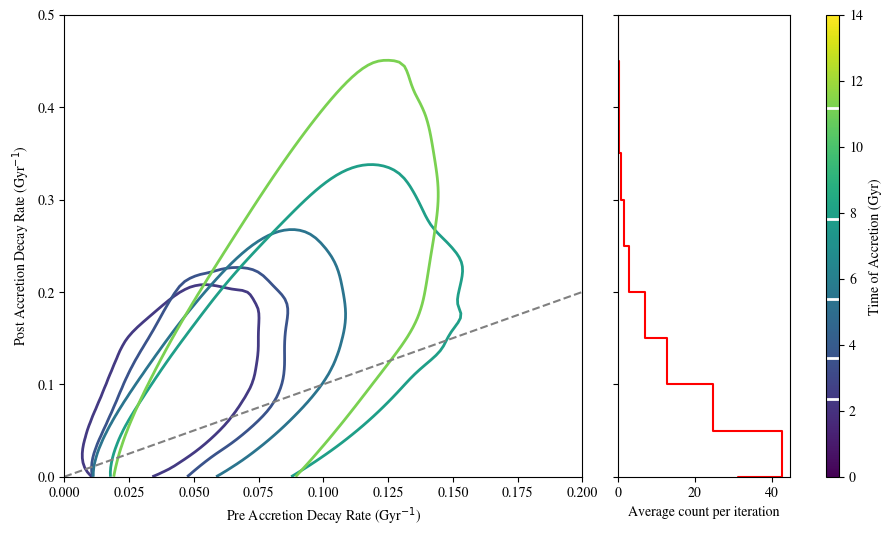

In [13]:
# ==================================================
# SETUP FIGURE: KDE | HISTOGRAM | COLORBAR
# ==================================================
fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[3, 1, 0.08], wspace=0.15)

ax = fig.add_subplot(gs[0, 0])  # KDE
ax_r = fig.add_subplot(gs[0, 1], sharey=ax)  # Histogram
cax = fig.add_subplot(gs[0, 2])  # Colorbar

sim = "m12i"

# --------------------------------------------------
# PARAMETERS (unchanged)
# --------------------------------------------------
xlim = (0, 0.2)
ylim = (0, 0.5)
min_gc_per_grp_avg = 5
epsilon = 1e-6
cmap = plt.get_cmap("viridis")

# --------------------------------------------------
# COMPUTE GROUP COUNTS AND TACC ACROSS ITERATIONS
# --------------------------------------------------
grp_counts = {}
grp_tacc = {}

for it_id in mass_dict[sim].keys():
    counts_in_it = {}
    for gcid in mass_dict[sim][it_id].keys():
        grp = mass_dict[sim][it_id][gcid]["grp"]
        tacc = mass_dict[sim][it_id][gcid]["tacc"]
        if tacc == -1:
            continue
        counts_in_it[grp] = counts_in_it.get(grp, 0) + 1
        grp_tacc.setdefault(grp, []).append(tacc)
    for grp, cnt in counts_in_it.items():
        grp_counts.setdefault(grp, []).append(cnt)

valid_grps = [grp for grp, counts in grp_counts.items() if np.mean(counts) >= min_gc_per_grp_avg]

# --------------------------------------------------
# BIN DATA BY GROUP
# --------------------------------------------------
binned_data = {grp: {"gamma_pre": [], "gamma_pos": [], "tacc": np.mean(grp_tacc[grp])} for grp in valid_grps}

for it_id in mass_dict[sim].keys():
    for gcid in mass_dict[sim][it_id].keys():
        grp = mass_dict[sim][it_id][gcid]["grp"]
        if grp not in valid_grps:
            continue
        if mass_dict[sim][it_id][gcid]["tacc"] == -1:
            continue
        binned_data[grp]["gamma_pre"].append(mass_dict[sim][it_id][gcid]["gamma_pre"])
        binned_data[grp]["gamma_pos"].append(mass_dict[sim][it_id][gcid]["gamma_pos"])


# --------------------------------------------------
# KDE CDF FUNCTION
# --------------------------------------------------
def kde_cdf_level(Z, frac=0.75):
    Zf = Z.ravel()
    idx = np.argsort(Zf)[::-1]
    Zs = Zf[idx]
    cdf = np.cumsum(Zs)
    cdf /= cdf[-1]
    return Zs[np.searchsorted(cdf, frac)]


# --------------------------------------------------
# LEFT PANEL — KDE CONTOURS
# --------------------------------------------------
all_tacc = [data["tacc"] for data in binned_data.values()]
norm = plt.Normalize(vmin=0, vmax=14)

xgrid = np.linspace(*xlim, 100)
ygrid = np.linspace(*ylim, 100)
X, Y = np.meshgrid(xgrid, ygrid)
grid_positions = np.vstack([X.ravel(), Y.ravel()])

for grp, data in binned_data.items():
    Z_list = []

    for it_id in mass_dict[sim].keys():
        x_it, y_it = [], []
        for gcid in mass_dict[sim][it_id].keys():
            if mass_dict[sim][it_id][gcid]["grp"] != grp:
                continue
            if mass_dict[sim][it_id][gcid]["tacc"] == -1:
                continue
            x_it.append(mass_dict[sim][it_id][gcid]["gamma_pre"])
            y_it.append(mass_dict[sim][it_id][gcid]["gamma_pos"])

        x_it = np.asarray(x_it)
        y_it = np.asarray(y_it)
        mask = np.isfinite(x_it) & np.isfinite(y_it)
        x_it, y_it = x_it[mask], y_it[mask]

        if len(x_it) < 5:
            continue

        x_it += np.random.normal(0, epsilon, len(x_it))
        y_it += np.random.normal(0, epsilon, len(y_it))

        Z = gaussian_kde(np.vstack([x_it, y_it]))(grid_positions).reshape(X.shape)
        Z /= Z.sum()
        Z_list.append(Z)

    if not Z_list:
        continue

    Z_avg = np.mean(Z_list, axis=0)
    level = kde_cdf_level(Z_avg, 0.75)

    ax.contour(
        X,
        Y,
        Z_avg,
        levels=[level],
        colors=[cmap(norm(data["tacc"]))],
        linewidths=2,
    )

ax.plot([0, 1], [0, 1], c="grey", ls="--")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel("Pre Accretion Decay Rate (Gyr$^{-1}$)")
ax.set_ylabel("Post Accretion Decay Rate (Gyr$^{-1}$)")

# --------------------------------------------------
# COLORBAR (MOVED TO RIGHTMOST AXIS)
# --------------------------------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label("Time of Accretion (Gyr)")

for tacc in all_tacc:
    cbar.ax.axhline(tacc, color="w", lw=2)

# --------------------------------------------------
# MIDDLE PANEL — FLIPPED HISTOGRAM
# --------------------------------------------------
bins = np.arange(-0.05, 0.7, 0.05)
res = None
n_iter = 0

for it_id in mass_dict[sim].keys():
    gam_lst = [
        mass_dict[sim][it_id][gcid]["gamma_ful"]
        for gcid in mass_dict[sim][it_id].keys()
        if mass_dict[sim][it_id][gcid]["grp"] == 0
    ]
    hx, _ = np.histogram(gam_lst, bins=bins)
    res = hx.astype(float) if res is None else res + hx
    n_iter += 1

avg = res / n_iter

ax_r.step(avg, bins[:-1], where="post", lw=1.5, c="r")
ax_r.set_xlabel("Average count per iteration")
ax_r.set_xlim(left=0)

ax_r.tick_params(axis="y", which="both", left=True, labelleft=False)

plt.show()

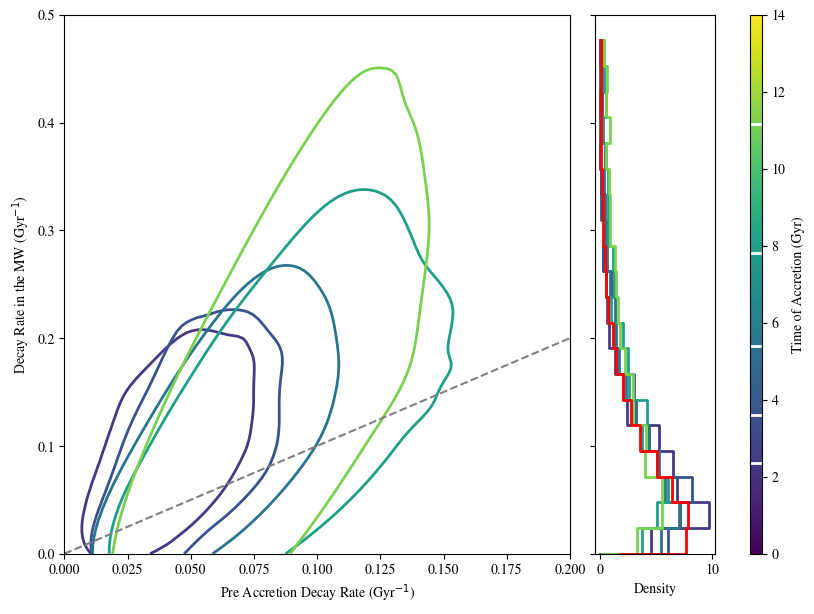

In [14]:
# ------------------------
# Settings
# ------------------------
sim = "m12i"
cont_level = 0.75  # enclosed KDE probability
hist_density = True  # DENSITY, not counts

xlim = (0.0, 0.2)
ylim = (0.0, 0.5)
epsilon = 1e-6
cmap = plt.get_cmap("viridis")
norm = plt.Normalize(vmin=0, vmax=14)

# ------------------------
# Figure & axes
# ------------------------
fig, ax = plt.subplots(figsize=(9, 7))
divider = make_axes_locatable(ax)

ax_histy = divider.append_axes("right", 1.2, pad=0.25, sharey=ax)
cax = divider.append_axes("right", 0.12, pad=0.35)

# ------------------------
# KDE Grid
# ------------------------
xgrid = np.linspace(*xlim, 100)
ygrid = np.linspace(*ylim, 100)
X, Y = np.meshgrid(xgrid, ygrid)
grid_positions = np.vstack([X.ravel(), Y.ravel()])

# ------------------------
# Histogram bins (Y only)
# ------------------------
histy_bins = np.linspace(*ylim, 22)
bin_width = np.diff(histy_bins)

# ------------------------
# Group bookkeeping
# ------------------------
grp_counts, grp_tacc = {}, {}

for it_id in mass_dict[sim]:
    cnt = {}
    for gcid in mass_dict[sim][it_id]:
        grp = mass_dict[sim][it_id][gcid]["grp"]
        tacc = mass_dict[sim][it_id][gcid]["tacc"]
        if tacc == -1:
            continue
        cnt[grp] = cnt.get(grp, 0) + 1
        grp_tacc.setdefault(grp, []).append(tacc)
    for g, v in cnt.items():
        grp_counts.setdefault(g, []).append(v)

valid_grps = [g for g in grp_counts if np.mean(grp_counts[g]) >= 5]

# ------------------------
# Accumulators (like your example)
# ------------------------
grp_data = {
    g: {
        "Z_list": [],
        "hist_sum": None,
        "n_iter": 0,
        "tacc": np.mean(grp_tacc[g]),
    }
    for g in valid_grps
}

# ------------------------
# Main loop (KDE + hist per iteration)
# ------------------------
for g in valid_grps:
    for it_id in mass_dict[sim]:
        x_it, y_it = [], []

        for gcid in mass_dict[sim][it_id]:
            d = mass_dict[sim][it_id][gcid]
            if d["grp"] != g or d["tacc"] == -1:
                continue
            x_it.append(d["gamma_pre"])
            y_it.append(d["gamma_pos"])

        x_it = np.asarray(x_it)
        y_it = np.asarray(y_it)
        m = np.isfinite(x_it) & np.isfinite(y_it)

        x_it, y_it = x_it[m], y_it[m]
        if len(x_it) < 5:
            continue

        # --- KDE ---
        xk = x_it + np.random.normal(0, epsilon, len(x_it))
        yk = y_it + np.random.normal(0, epsilon, len(y_it))

        kde = gaussian_kde(np.vstack([xk, yk]))
        Z = kde(grid_positions).reshape(X.shape)
        Z /= Z.sum()  # equal iteration weight
        grp_data[g]["Z_list"].append(Z)

        # --- Histogram (density) ---
        hy, _ = np.histogram(y_it, bins=histy_bins, density=hist_density)
        grp_data[g]["hist_sum"] = hy if grp_data[g]["hist_sum"] is None else grp_data[g]["hist_sum"] + hy
        grp_data[g]["n_iter"] += 1

# ------------------------
# Plot contours + histograms
# ------------------------
for g, d in grp_data.items():
    if not d["Z_list"]:
        continue

    # --- Average KDE ---
    Z_avg = np.mean(d["Z_list"], axis=0)

    # --- CDF contour level ---
    Zf = Z_avg.ravel()
    idx = np.argsort(Zf)[::-1]
    Zs = Zf[idx]
    cdf = np.cumsum(Zs)
    cdf /= cdf[-1]
    level = Zs[np.searchsorted(cdf, cont_level)]

    color = cmap(norm(d["tacc"]))

    ax.contour(X, Y, Z_avg, levels=[level], colors=[color], linewidths=2)

    # --- Average histogram (density) ---
    hy_avg = d["hist_sum"] / d["n_iter"]
    ax_histy.step(hy_avg, histy_bins[:-1], where="post", lw=2, color=color)

# ------------------------
# In-situ histogram (RED)
# ------------------------
hist_insitu = None
n_iter = 0

for it_id in mass_dict[sim]:
    y = [
        mass_dict[sim][it_id][gcid]["gamma_ful"]
        for gcid in mass_dict[sim][it_id]
        if mass_dict[sim][it_id][gcid]["grp"] == 0
    ]
    hy, _ = np.histogram(y, bins=histy_bins, density=hist_density)
    hist_insitu = hy if hist_insitu is None else hist_insitu + hy
    n_iter += 1

ax_histy.step(hist_insitu / n_iter, histy_bins[:-1], where="post", color="red", lw=2)

# ------------------------
# Formatting
# ------------------------
ax.plot([0, 1], [0, 1], ls="--", c="grey")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel("Pre Accretion Decay Rate (Gyr$^{-1}$)")
# ax.set_ylabel("Post Accretion Decay Rate (Gyr$^{-1}$)")
ax.set_ylabel("Decay Rate in the MW (Gyr$^{-1}$)")

# ax_histy.invert_xaxis()
# ax_histy.invert_yaxis()
ax_histy.set_xlabel("Density")
ax_histy.tick_params(labelleft=False)

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
plt.colorbar(sm, cax=cax, label="Time of Accretion (Gyr)")

for tacc in all_tacc:
    cax.axhline(tacc, color="w", lw=2)


plt.show()

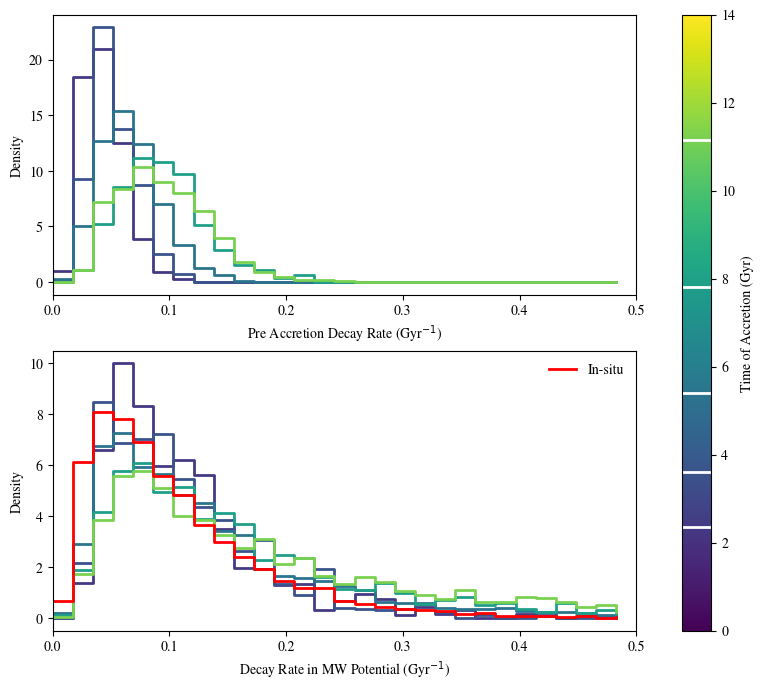

In [15]:
# ------------------------
# Figure setup
# ------------------------

fig = plt.figure(figsize=(8.5, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[20, 1], wspace=0.15)

ax_pre = fig.add_subplot(gs[0, 0])
ax_post = fig.add_subplot(gs[1, 0], sharex=ax_pre)

cax = fig.add_subplot(gs[:, 1])  # colour bar spans both rows


# ------------------------
# Histogram bins
# ------------------------
bins = np.linspace(0.0, 0.5, 30)

# ------------------------
# Accumulators
# ------------------------
pre_hist = {g: {"sum": None, "n": 0} for g in valid_grps}
post_hist = {g: {"sum": None, "n": 0} for g in valid_grps}

# ------------------------
# Accreted populations
# ------------------------
for g in valid_grps:
    for it_id in mass_dict[sim]:
        pre, post = [], []

        for gcid in mass_dict[sim][it_id]:
            d = mass_dict[sim][it_id][gcid]
            if d["grp"] != g or d["tacc"] == -1:
                continue
            pre.append(d["gamma_pre"])
            post.append(d["gamma_pos"])

        pre = np.asarray(pre)
        post = np.asarray(post)
        m = np.isfinite(pre) & np.isfinite(post)
        pre, post = pre[m], post[m]

        if len(pre) < 5:
            continue

        hpre, _ = np.histogram(pre, bins=bins, density=True)
        hpost, _ = np.histogram(post, bins=bins, density=True)

        pre_hist[g]["sum"] = hpre if pre_hist[g]["sum"] is None else pre_hist[g]["sum"] + hpre
        post_hist[g]["sum"] = hpost if post_hist[g]["sum"] is None else post_hist[g]["sum"] + hpost

        pre_hist[g]["n"] += 1
        post_hist[g]["n"] += 1

# ------------------------
# Plot accreted PDFs
# ------------------------
for g in valid_grps:
    if pre_hist[g]["n"] == 0:
        continue

    color = cmap(norm(grp_data[g]["tacc"]))

    pre_avg = pre_hist[g]["sum"] / pre_hist[g]["n"]
    post_avg = post_hist[g]["sum"] / post_hist[g]["n"]

    ax_pre.step(bins[:-1], pre_avg, where="post", lw=2, color=color)

    ax_post.step(bins[:-1], post_avg, where="post", lw=2, color=color)

# ------------------------
# In-situ (POST only)
# ------------------------
hist_insitu = None
n_iter = 0

for it_id in mass_dict[sim]:
    post = [
        mass_dict[sim][it_id][gcid]["gamma_ful"]
        for gcid in mass_dict[sim][it_id]
        if mass_dict[sim][it_id][gcid]["grp"] == 0 and np.isfinite(mass_dict[sim][it_id][gcid]["gamma_ful"])
    ]

    if len(post) < 5:
        continue

    h, _ = np.histogram(post, bins=bins, density=True)
    hist_insitu = h if hist_insitu is None else hist_insitu + h
    n_iter += 1

ax_post.step(bins[:-1], hist_insitu / n_iter, where="post", lw=2, color="red", label="In-situ")

# ------------------------
# Formatting
# ------------------------
ax_pre.set_ylabel("Density")
ax_pre.set_xlabel("Pre Accretion Decay Rate (Gyr$^{-1}$)")
ax_post.set_ylabel("Density")
# ax_post.set_xlabel("Post Accretion Decay Rate (Gyr$^{-1}$)")
ax_post.set_xlabel("Decay Rate in MW Potential (Gyr$^{-1}$)")

# ax_pre.set_title("Pre-accretion decay rate")
# ax_post.set_title("Post-accretion decay rate (MW)")

ax_pre.set_xlim(0.0, 0.5)
ax_post.legend(frameon=False)


sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = plt.colorbar(sm, cax=cax)
cbar.set_label("Time of Accretion (Gyr)")

for tacc in all_tacc:
    cax.axhline(tacc, color="w", lw=2)

plt.show()

# GIF

In [16]:
def sep_func(x, y, msk):
    x_is = x[msk]
    y_is = y[msk]

    x_id = x[~msk]
    y_id = y[~msk]

    # Stack features in log10 space
    Xd = np.stack((np.log10(x_id), np.log10(y_id)), axis=1)
    Xs = np.stack((np.log10(x_is), np.log10(y_is)), axis=1)
    Xds = np.vstack((Xd, Xs))

    y = np.array([0] * len(Xd) + [1] * len(Xs))  # labels

    # Train linear SVM
    clf = SVC(kernel="linear")
    clf.fit(Xds, y)

    # Decision boundary in log10 space
    w = clf.coef_[0]
    b = clf.intercept_[0]

    m = -(w[0] / w[1])
    c = -(b / w[1])

    return m, c

In [17]:
m_lst = [[], []]
b_lst = [[], []]
for acc in [0, 1]:
    for it_id in sim_dict[sim].keys():
        if acc == 0:
            amsk = sim_dict[sim][it_id]["acc"]
        else:
            amsk = ~sim_dict[sim][it_id]["acc"]

        x = sim_dict[sim][it_id]["m_tfo"][amsk]
        y = sim_dict[sim][it_id]["t_tz0"][amsk]

        smsk = sim_dict[sim][it_id]["s_tz0"][amsk]

        m, b = sep_func(x, y, smsk)
        m_lst[acc].append(m)
        b_lst[acc].append(b)

# m_in = np.mean(m_lst[0])
# b_in = np.mean(b_lst[0])

# m_ex = np.mean(m_lst[1])
# b_ex = np.mean(b_lst[1])

Text(0, 0.5, '$\\mathrm{P}_{z=0}$ (Myr)')

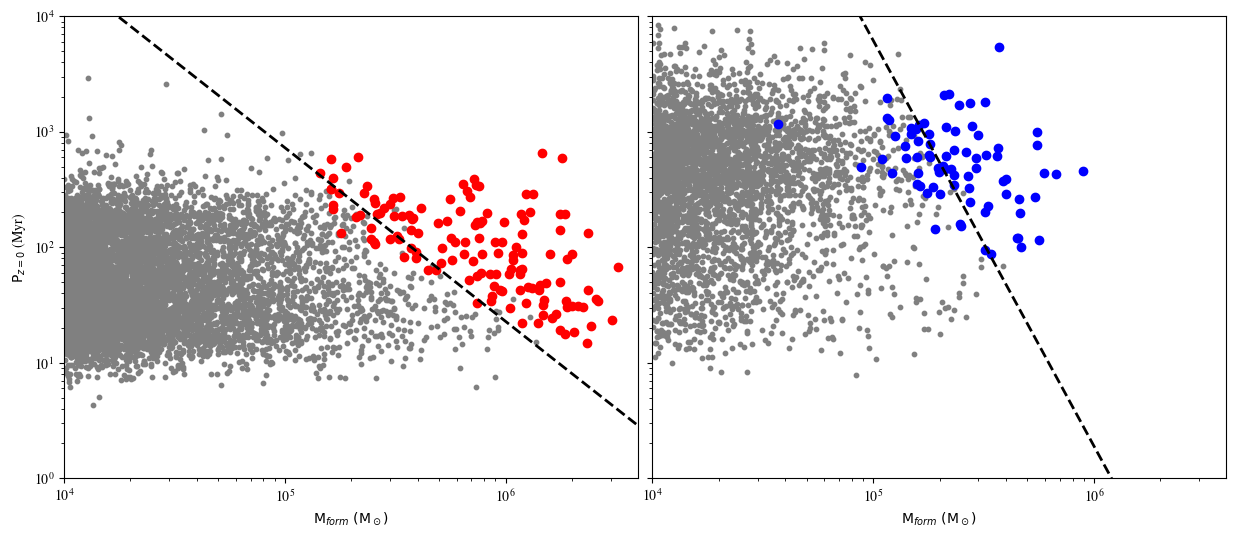

In [18]:
sim = "m12i"
it_id = "it000"

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.025)

sim_dict[sim][it_id].keys()

for acc in [0, 1]:
    smsk = sim_dict[sim][it_id]["s_tz0"]
    if acc == 0:
        amsk = sim_dict[sim][it_id]["acc"]
        acol = "r"
    else:
        amsk = ~sim_dict[sim][it_id]["acc"]
        acol = "b"
    surmsk = smsk & amsk
    deamsk = ~smsk & amsk

    xa = sim_dict[sim][it_id]["m_tfo"][surmsk]
    ya = sim_dict[sim][it_id]["t_tz0"][surmsk]

    xd = sim_dict[sim][it_id]["m_tfo"][deamsk]
    yd = sim_dict[sim][it_id]["t_tz0"][deamsk]

    ax = axs[acc]
    ax.scatter(xd, yd, c="grey", s=10)
    ax.scatter(xa, ya, c=acol)

    m = np.mean(m_lst[acc])
    b = np.mean(b_lst[acc])

    xfit = np.logspace(3, 7)
    xfitlog = np.log10(xfit)

    yfitlog = xfitlog * m + b
    yfit = 10**yfitlog

    ax.plot(xfit, yfit, c="k", ls="--", lw=2)

for ax in axs:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$\mathrm{M}_{form}\ (\mathrm{M}_\odot)$")

    ax.set_xlim(10**4, 10**6.6)
    ax.set_ylim(10**0, 10**4)

axs[0].set_ylabel(r"$\mathrm{P}_{z=0}$ (Myr)")


In [28]:
def fig_to_pil(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
    buf.seek(0)
    img = Image.open(buf)
    return img.copy()  # detach from buffer


res_dir = "../data/results"
os.makedirs(res_dir, exist_ok=True)

# gif_file = res_dir + "/" + "disruption_age" + ".gif"
gif_file = res_dir + "/" + "disruption_time" + ".gif"

frames = []  # Pillow frames

sim = "m12i"
it_id = "it000"
cmap = "spring"
# cmap = "Wistia_r"

tlims = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
for tlim in tlims:
    fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
    plt.subplots_adjust(wspace=0.025)

    for acc in [0, 1]:
        smsk = sim_dict[sim][it_id]["s_tz0"]

        if acc == 0:
            amsk = sim_dict[sim][it_id]["acc"]
            acol = "r"
        else:
            amsk = ~sim_dict[sim][it_id]["acc"]
            acol = "b"

        surmsk = smsk & amsk
        deamsk = ~smsk & amsk

        xa = sim_dict[sim][it_id]["m_tfo"][surmsk]
        ya = sim_dict[sim][it_id]["t_tz0"][surmsk]

        # tmsk = sim_dict[sim][it_id]["age_p"] <= tlim
        tmsk = sim_dict[sim][it_id]["tdis"] <= tlim

        xdb = sim_dict[sim][it_id]["m_tfo"][deamsk & tmsk]
        ydb = sim_dict[sim][it_id]["t_tz0"][deamsk & tmsk]
        # cdb = sim_dict[sim][it_id]["age_p"][deamsk & tmsk]
        cdb = sim_dict[sim][it_id]["tdis"][deamsk & tmsk]

        xda = sim_dict[sim][it_id]["m_tfo"][deamsk & ~tmsk]
        yda = sim_dict[sim][it_id]["t_tz0"][deamsk & ~tmsk]

        ax = axs[acc]

        ax.scatter(xda, yda, c="grey", s=5)
        sc = ax.scatter(xdb, ydb, c=cdb, s=10, cmap=cmap, vmin=0, vmax=10)
        ax.scatter(xa, ya, c=acol)

        m = np.mean(m_lst[acc])
        b = np.mean(b_lst[acc])

        xfit = np.logspace(3, 7)
        yfit = 10 ** (np.log10(xfit) * m + b)
        ax.plot(xfit, yfit, c="k", ls="--", lw=2)

    for ax in axs:
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(r"$\mathrm{M}_{form}\ (\mathrm{M}_\odot)$")
        ax.set_xlim(1e4, 10**6.6)
        ax.set_ylim(1e0, 1e4)

    axs[0].set_ylabel(r"$\mathrm{P}_{z=0}$ (Myr)")

    # --- tlim label ---
    axs[0].text(
        0.98,
        0.98,
        rf"$t_{{\rm disrupt}} < {tlim}\ \mathrm{{Gyr}}$",
        transform=axs[0].transAxes,
        ha="right",
        va="top",
    )

    # --- colorbar ---
    cax = fig.add_axes([0.15, 0.92, 0.70, 0.025])
    cbar = fig.colorbar(sc, cax=cax, orientation="horizontal")
    # cbar.set_label("Age at Disruption (Gyr)")
    cbar.set_label("Time of Disruption (Gyr)")
    cbar.ax.xaxis.set_label_position("top")
    cbar.ax.xaxis.tick_top()

    # ---- convert frame ----
    frame = fig_to_pil(fig)
    frames.append(frame)

    plt.close(fig)

frames[0].save(
    gif_file,
    save_all=True,
    append_images=frames[1:],
    duration=150,  # ms per frame (~6–7 fps)
    loop=0,
)

print(f"Saved GIF → {gif_file}")


Saved GIF → ../data/results/disruption_time.gif


# Boundaries

In [20]:
def plot_lim(x, y, msk):
    x_is = x[msk]
    y_is = y[msk]

    x_id = x[~msk]
    y_id = y[~msk]

    # Stack features in log10 space
    Xd = np.stack((np.log10(x_id), np.log10(y_id)), axis=1)
    Xs = np.stack((np.log10(x_is), np.log10(y_is)), axis=1)
    Xds = np.vstack((Xd, Xs))

    y = np.array([0] * len(Xd) + [1] * len(Xs))  # labels

    # Train linear SVM
    clf = SVC(kernel="linear")
    clf.fit(Xds, y)

    # Decision boundary in log10 space
    w = clf.coef_[0]
    b = clf.intercept_[0]

    m = -(w[0] / w[1])
    c = -(b / w[1])

    return m, c


def life_cut(x, y, c, c_level, xfitlog, plot=True, ytlog=0.7, label=None):
    msk = c <= c_level
    m, b = plot_lim(x, y, msk)

    print(m, b)

    yfitlog = m * xfitlog + b
    yfit = 10**yfitlog

    if not plot:
        return yfit

    if label is None:
        label = f"{c_level} Gyr"
    plt.plot(xfit, yfit, c="grey", ls="--")

    # --- label position (on the line) ---
    xtlog = (ytlog - b) / m
    # x0, y0 = 10**xtlog, 10**ytlog

    ax = plt.gca()

    # compute screen-space angle
    dx = 0.1
    x1log, x2log = xtlog, xtlog + dx
    y1log = m * x1log + b
    y2log = m * x2log + b

    p1 = ax.transData.transform((10**x1log, 10**y1log))
    p2 = ax.transData.transform((10**x2log, 10**y2log))

    angle = np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))

    # --- offset perpendicular to the line (in pixels) ---
    offset_pixels = 17  # increase for more separation

    normal = np.array([-(p2[1] - p1[1]), p2[0] - p1[0]])
    normal = normal / np.linalg.norm(normal)

    p_text = p1 + offset_pixels * normal

    # convert back to data coords
    x_text, y_text = ax.transData.inverted().transform(p_text)

    plt.text(
        x_text,
        y_text,
        label,
        rotation=angle,
        rotation_mode="anchor",
        ha="left",
        va="top",
        color="grey",
        bbox=dict(facecolor="none", alpha=0.6, edgecolor="none"),
        zorder=5,
    )


def lower_envelope(x, m, x_b, y_b):
    return np.where(x < x_b, m * (x - x_b) + y_b, y_b)


def kde_threshold(Z, fraction):
    """Return KDE level that encloses fraction of total probability."""
    sorted_Z = np.sort(Z.ravel())[::-1]  # descending
    cumsum = np.cumsum(sorted_Z)
    cumsum /= cumsum[-1]  # normalize
    # Find the smallest Z value where cumulative sum >= fraction
    level = sorted_Z[np.searchsorted(cumsum, fraction)]
    return level


def plot_bounding(it_dict, fraction=0.98, in_msk=True):
    x = np.array([])
    y = np.array([])
    # c = np.array([])

    for it_id in it_dict.keys():
        if in_msk:
            msk_i = it_dict[it_id]["s_tz0"] & sim_dict[sim][it_id]["acc"]
        else:
            msk_i = it_dict[it_id]["s_tz0"] & ~sim_dict[sim][it_id]["acc"]
        x_i = it_dict[it_id]["m_tz0"][msk_i]
        y_i = it_dict[it_id]["t_tz0"][msk_i]
        # c_i = it_dict[it_id]["ml"][msk_i]
        # c_i = it_dict[it_id]["age_p"][msk_i]

        x = np.concatenate((x, x_i))
        y = np.concatenate((y, y_i))
        # c = np.concatenate((c, c_i))

    xlog = np.log10(x)
    ylog = np.log10(y)

    xy = np.vstack([xlog, ylog])
    kde = gaussian_kde(xy)
    xmin, xmax = xlog.min(), xlog.max()
    ymin, ymax = ylog.min(), ylog.max()

    X, Y = np.meshgrid(np.linspace(xmin, xmax, 200), np.linspace(ymin, ymax, 200))
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    level = kde_threshold(Z, fraction)
    cont = plt.contour(X, Y, Z, levels=[level], colors="orange")
    plt.close()

    contour_path = cont.collections[0].get_paths()[0]
    vertices = contour_path.vertices
    x_contour, y_contour = vertices[:, 0], vertices[:, 1]

    # --- Keep only the "lower" part of the contour ---
    # We'll bin x values and take the minimum y in each bin
    bins = np.linspace(x_contour.min(), x_contour.max(), 100)
    x_bin_centers = 0.5 * (bins[:-1] + bins[1:])
    y_lower = []
    x_lower = []

    for i in range(len(bins) - 1):
        mask = (x_contour >= bins[i]) & (x_contour < bins[i + 1])
        if np.any(mask):
            x_lower.append(x_bin_centers[i])
            y_lower.append(np.min(y_contour[mask]))

    x_lower = np.array(x_lower)
    y_lower = np.array(y_lower)

    # --- Fit lower-envelope function ---
    p0 = [-1, np.median(x_lower), np.median(y_lower)]  # initial guess: slope, x_b, y_b
    params, cov = curve_fit(lower_envelope, x_lower, y_lower, p0=p0)

    xfit = np.logspace(1, 7)
    xfitlog = np.log10(xfit)
    yfitlog = lower_envelope(xfitlog, *params)
    yfit = 10**yfitlog

    plot_dict = {"xfit": xfit, "yfit": yfit, "params": params, "cov": cov}

    return plot_dict

-14.191394673698472 -345.5547063397897


/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_23031/1199788435.py:135: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  contour_path = cont.collections[0].get_paths()[0]


(1, 10000)

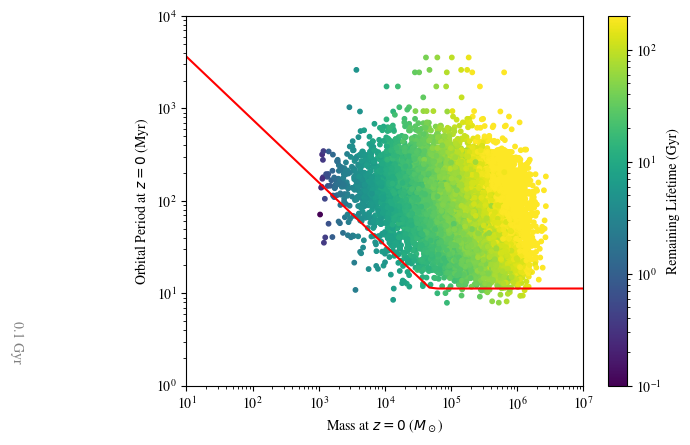

In [21]:
in_msk = True
plot_boundary = True
plot_lifecut = True
Mmin = 1000

x = []
y = []
c = []

for it_id in mass_dict[sim].keys():
    for gcid in mass_dict[sim][it_id].keys():
        if mass_dict[sim][it_id][gcid]["amsk"] == in_msk:
            if in_msk:
                gam = mass_dict[sim][it_id][gcid]["gamma_ful"]
            else:
                gam = mass_dict[sim][it_id][gcid]["gamma_pos"]

            mz0 = mass_dict[sim][it_id][gcid]["mz0"]
            t_left = np.log(mz0 / Mmin) * (1 / gam)

            if t_left < 0:
                continue

            x.append(mass_dict[sim][it_id][gcid]["mz0"])
            y.append(mass_dict[sim][it_id][gcid]["pz0"])
            c.append(t_left)

        else:
            continue

x = np.array(x)
y = np.array(y)
c = np.array(c)

plt.figure(figsize=(9, 7))

if in_msk:
    col = "r"
else:
    col = "b"

if plot_boundary:
    plot_dict = plot_bounding(sim_dict[sim], fraction=0.98, in_msk=in_msk)
    plt.plot(plot_dict["xfit"], plot_dict["yfit"], c=col)

if plot_lifecut:
    life_cut(x, y, c, 0.1, xfitlog)
#     life_cut(x, y, c, 1, xfitlog)
# life_cut(x, y, c, 5, xfitlog)
# life_cut(x, y, c, time, xfitlog, label="Hubble Time")

plt.scatter(x, y, c=c, s=10, norm=LogNorm(vmin=10**-1, vmax=2 * 10**2))
plt.colorbar(label=r"Remaining Lifetime (Gyr)")

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"Mass at $z=0$ ($M_\odot$)")
plt.ylabel(r"Orbital Period at $z=0$ (Myr)")

plt.xlim(10**1, 10**7)
plt.ylim(10**0, 10**4)

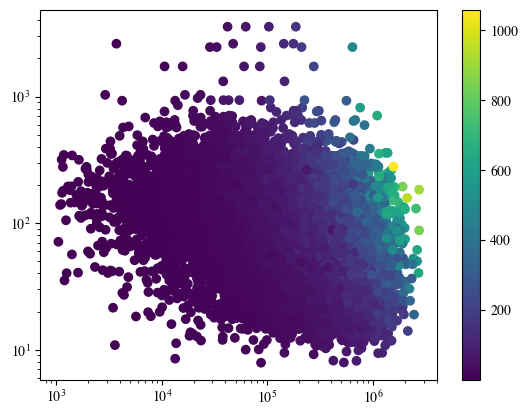

In [22]:
plt.scatter(x, y, c=c, vmin=1, vmax=None)
plt.colorbar()
plt.xscale("log")
plt.yscale("log")

In [23]:
c[c < 1]

array([0.48245045, 0.33585258, 0.75916309, 0.40146632, 0.68819362,
       0.18791332, 0.80435068, 0.36471926, 0.09682179, 0.70635028,
       0.28601659, 0.24026062, 0.39167417, 0.35769401, 0.98737173,
       0.64041492, 0.29036301, 0.95356526, 0.94808344])

/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_23031/1163187870.py:9: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


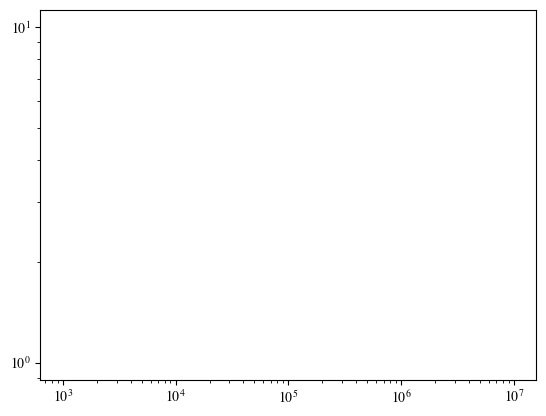

In [24]:
msk = c <= 0.1
m, b = plot_lim(x, y, msk)

yfitlog = m * xfitlog + b
yfit = 10**yfitlog

plt.plot(xfit, yfit, c="grey", ls="--")
plt.xscale("log")
plt.yscale("log")